In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('diabetes_unclean.csv')

# 1. Drop the "ID" and "No_Pation" columns 
df = df.drop(columns=['ID', 'No_Pation'])

# 2. Correct misspelled values in the "Gender" column 
# The dataset contains variations like 'f', 'F ', ' M' 
df['Gender'] = df['Gender'].str.strip().str.upper()

# Clean the target variable 'CLASS' as it contains trailing spaces like 'N ', 'Y '
df['CLASS'] = df['CLASS'].str.strip()

# 3. Handle missing values 
# Filling numerical columns with the mean
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].mean())

# 4. Perform one-hot encoding on categorical columns except the target 
df = pd.get_dummies(df, columns=['Gender'], drop_first=False)

# Separate features (X) and target (y)
X = df.drop(columns=['CLASS'])
y = df['CLASS']

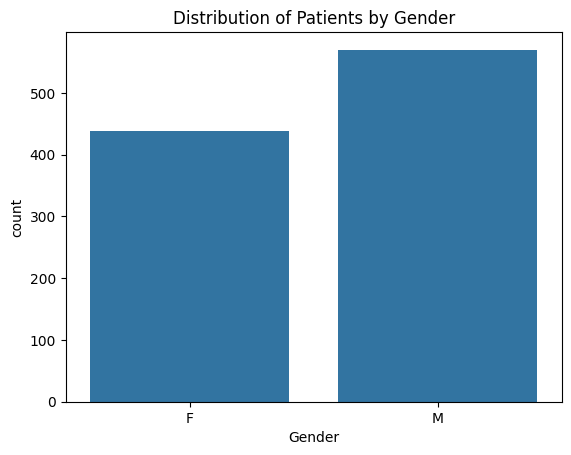

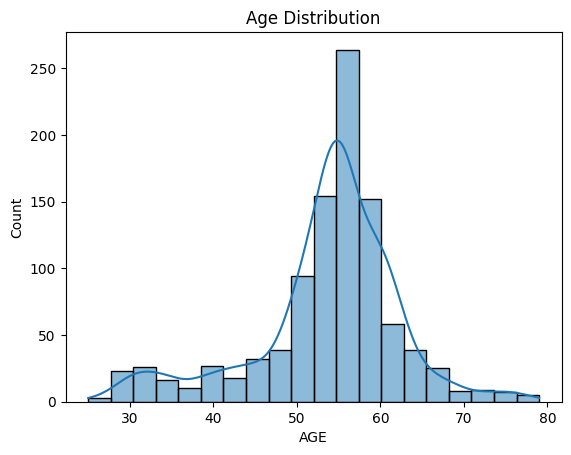

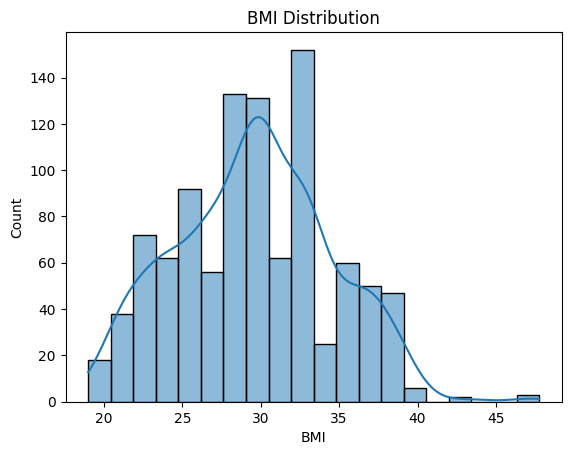

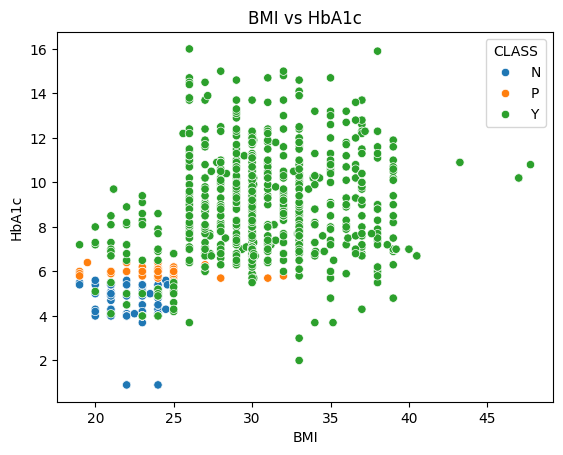

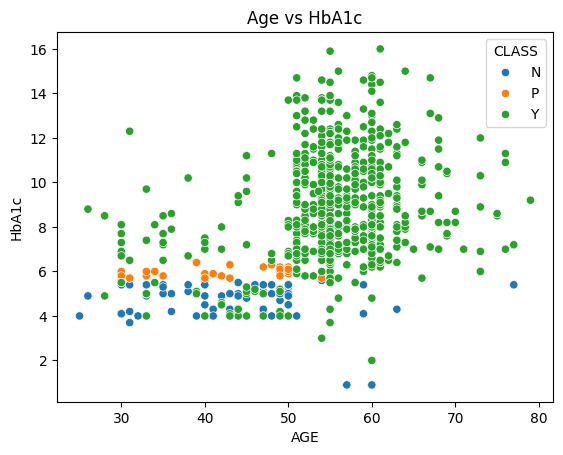

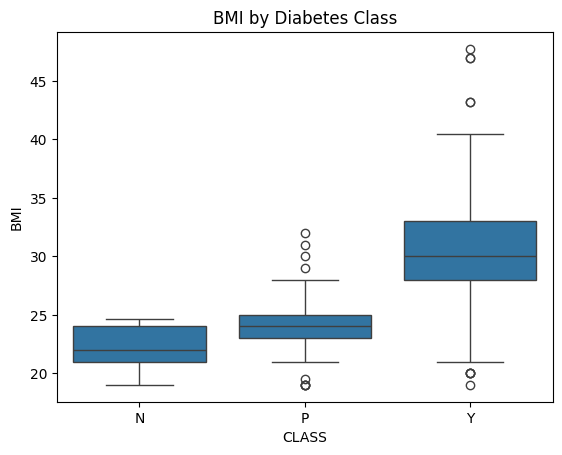

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Bar chart: Male vs Female patients 
plt.figure()
sns.countplot(x='Gender', data=pd.read_csv('diabetes_unclean.csv').assign(Gender=lambda x: x['Gender'].str.strip().str.upper()))
plt.title('Distribution of Patients by Gender')
plt.show()

# 2. Histogram: Age distribution 
plt.figure()
sns.histplot(df['AGE'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

# 3. Histogram: BMI distribution 
plt.figure()
sns.histplot(df['BMI'], bins=20, kde=True)
plt.title('BMI Distribution')
plt.show()

# 4. Scatter plot: BMI vs HbA1c (color-coded by CLASS) 
plt.figure()
sns.scatterplot(x='BMI', y='HbA1c', hue=df['CLASS'], data=df)
plt.title('BMI vs HbA1c')
plt.show()

# 5. Scatter plot: Age vs HbA1c (color-coded by CLASS) 
plt.figure()
sns.scatterplot(x='AGE', y='HbA1c', hue=df['CLASS'], data=df)
plt.title('Age vs HbA1c')
plt.show()

# 6. Box plot: BMI of diabetic vs non-diabetic 
plt.figure()
sns.boxplot(x='CLASS', y='BMI', data=df)
plt.title('BMI by Diabetes Class')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import joblib

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Initialize models 
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

results = []

# Train and Evaluate 
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average='weighted', zero_division=0)
    })

# Create comparison table 
results_df = pd.DataFrame(results)
print(results_df)

d:\mlops-diabetes-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.943894   0.939275  0.943894  0.939760
1                  SVM  0.848185   0.719417  0.848185  0.778512
2        Decision Tree  0.986799   0.986781  0.986799  0.986668
3        Random Forest  0.990099   0.990125  0.990099  0.990022
4                  KNN  0.904290   0.915995  0.904290  0.909256


In [ ]:
# 1. Select the best performing model 
best_model = models["Random Forest"] 

# 2. Save the model 
joblib.dump(best_model, 'diabetes_model.pkl')

# 3. Save the training columns 
training_columns = X_train.columns.tolist()
joblib.dump(training_columns, 'training_columns.pkl')

['training_columns.pkl']